In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import tensorflow as tf
import random
import os
from sklearn.model_selection import KFold
import datetime

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import KFold
import numpy as np


In [3]:
# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'

In [4]:
# File paths
file_paths = {
    "B0005": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0005_ALL_FEATURES_NEW.csv",
    "B0006": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0006_ALL_FEATURES_NEW.csv",
    "B0007": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0007_ALL_FEATURES_NEW.csv",
    "B0018": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0018_ALL_FEATURES_NEW.csv"
}

In [5]:
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)
      # Drop specified columns
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3'])
    #group 1
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3','CV_CT', 'dQ_dV_peak_positionV'])
    
    # group 2
    data = data.drop(columns=['CC_CT','CV_CT','Ratio_CCCT_CVCT','C_TEMP_MAX','dQ_dV_peak','dQ_dV_peak_positionV','Original_Signal'])

    #group 1 and 2
    #data = data.drop(columns=['CV_CT','dQ_dV_peak', 'dQ_dV_peak_positionV'])
    return data

In [6]:
def create_sliding_window(data, window_size, target_column_index):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, :])
        y.append(data[i + window_size, target_column_index])
    return np.array(X), np.array(y)

In [35]:
# Define parameters
window_size = 8
Batch_Size = 32
train_files = ["B0005", "B0006", "B0007"]
test_file = "B0018"

In [36]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)

In [37]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [38]:
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the CNN model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the CNN model
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])),
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    
    # Compile model
    model.compile(optimizer='adam', loss='mse')
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store metrics
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Evaluate on test data
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on test data
y_pred = model.predict(X_test)

# Inverse transform predictions
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]
y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]


Combined training data shape: (480, 8, 4)
Combined target data shape: (480,)
Test data shape: (124, 8, 4)

Training on fold 1
Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 0.0668 - val_loss: 0.0110
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0060 - val_loss: 0.0015
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0029 - val_loss: 0.0032
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 9.3441e-04 - val_loss: 8.2123e-04
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 6.0551e-04 - val_loss: 7.4552e-04
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4.7688e-04 - val_loss: 5.1675e-04
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 4.2799e-04 - val_loss: 4.5112e-04
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 4.0383e-04 - val_loss: 4.4979e-04
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/st

In [39]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")


Final Model Performance Metrics:
Mean Absolute Error (MAE): 0.0042413350
Mean Squared Error (MSE): 0.0000483142
Root Mean Squared Error (RMSE): 0.0069508392
R2 Score: 0.9903946
Mean Absolute Percentage Error (MAPE): 0.5454701%


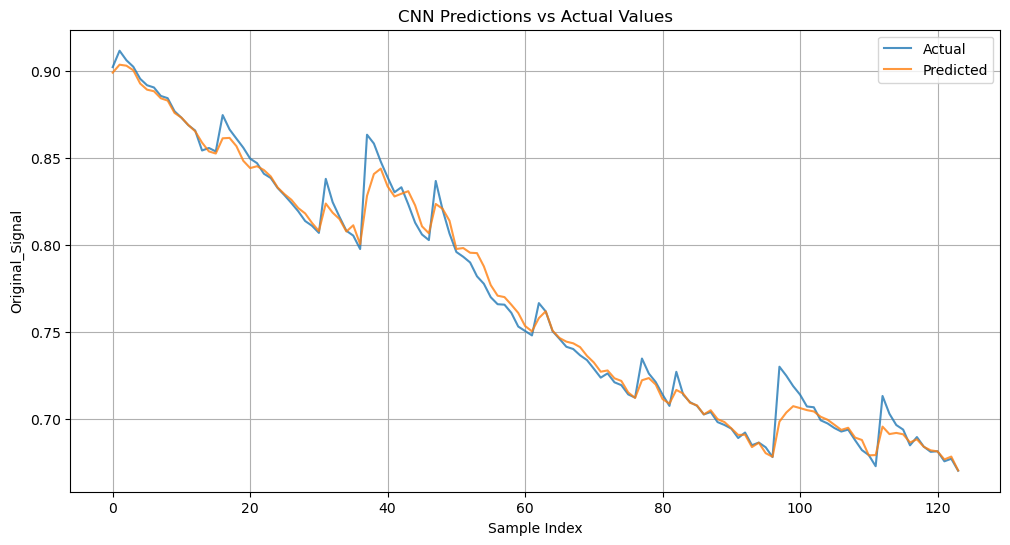


Output shapes:
Actual values shape: (124,)
Predicted values shape: (124,)


In [40]:
 #Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("CNN Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")

In [41]:
#B0005

In [51]:
# Define parameters
window_size = 8
Batch_Size = 32
train_files = ["B0018", "B0006", "B0007"]
test_file = "B0005"

In [52]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)

In [53]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [54]:
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the CNN model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the CNN model
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])),
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    
    # Compile model
    model.compile(optimizer='adam', loss='mse')
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store metrics
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Evaluate on test data
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on test data
y_pred = model.predict(X_test)

# Inverse transform predictions
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]
y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]


Combined training data shape: (444, 8, 4)
Combined target data shape: (444,)
Test data shape: (160, 8, 4)

Training on fold 1
Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 0.0854 - val_loss: 0.0247
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0113 - val_loss: 0.0065
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0064 - val_loss: 0.0036
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0016 - val_loss: 0.0013
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0014 - val_loss: 9.2681e-04
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 9.0500e-04 - val_loss: 8.1112e-04
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 8.2306e-04 - val_loss: 8.2264e-04
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 8.0229e-04 - val_loss: 7.1173e-04
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 

In [56]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")


Final Model Performance Metrics:
Mean Absolute Error (MAE): 0.0018284487
Mean Squared Error (MSE): 0.0000074557
Root Mean Squared Error (RMSE): 0.0027305138
R2 Score: 0.9991264
Mean Absolute Percentage Error (MAPE): 0.2354780%


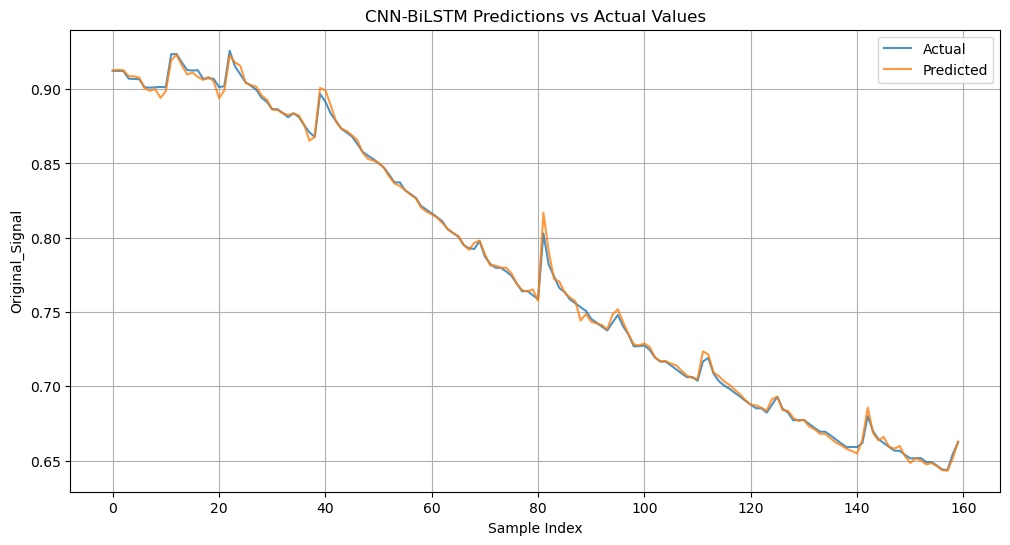


Output shapes:
Actual values shape: (160,)
Predicted values shape: (160,)


In [57]:
 #Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("CNN  Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")

In [58]:
#B0006

In [59]:
# Define parameters
window_size = 8
Batch_Size = 32
train_files = ["B0005", "B0018", "B0007"]
test_file = "B0006"

In [60]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)

In [61]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [62]:
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the CNN model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the CNN model
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])),
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    
    # Compile model
    model.compile(optimizer='adam', loss='mse')
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store metrics
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Evaluate on test data
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on test data
y_pred = model.predict(X_test)

# Inverse transform predictions
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]
y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]


Combined training data shape: (444, 8, 4)
Combined target data shape: (444,)
Test data shape: (160, 8, 4)

Training on fold 1
Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - loss: 0.0502 - val_loss: 0.0140
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0050 - val_loss: 0.0013
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0028 - val_loss: 0.0023
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0020 - val_loss: 0.0015
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0013 - val_loss: 7.7765e-04
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 9.3254e-04 - val_loss: 7.4623e-04
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 8.2006e-04 - val_loss: 6.2926e-04
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 7.7413e-04 - val_loss: 5.7414e-04
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 7.6032e-04 - val_loss: 5.3265e-04
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step 

In [64]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")


Final Model Performance Metrics:
Mean Absolute Error (MAE): 0.0039674733
Mean Squared Error (MSE): 0.0000262511
Root Mean Squared Error (RMSE): 0.0051235812
R2 Score: 0.9980909
Mean Absolute Percentage Error (MAPE): 0.5246956%


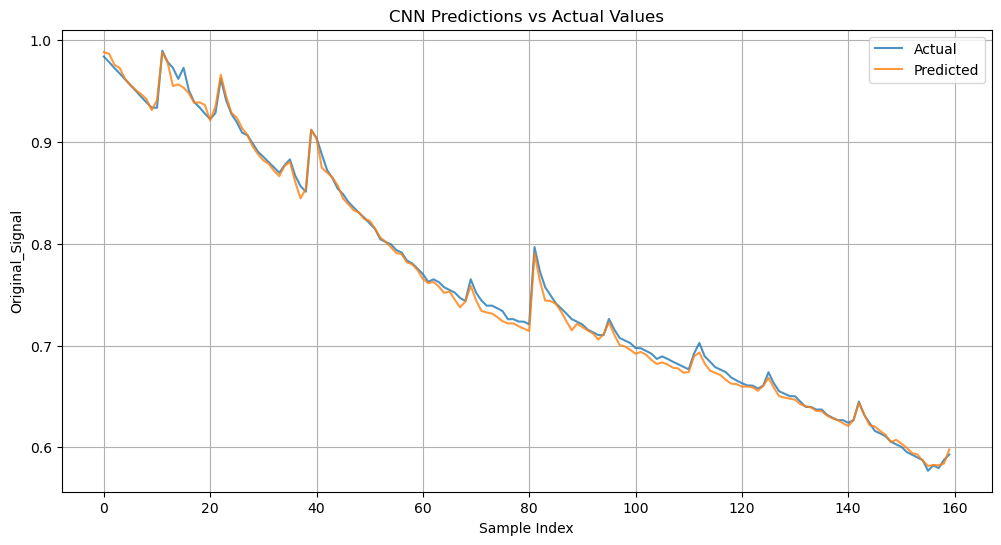


Output shapes:
Actual values shape: (160,)
Predicted values shape: (160,)


In [66]:
 #Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("CNN Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")

# B0007

In [7]:
# Define parameters
window_size = 8
Batch_Size = 32
train_files = ["B0005", "B0006", "B0018"]
test_file = "B0007"

In [8]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)

In [9]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [10]:
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the CNN model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the CNN model
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])),
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    
    # Compile model
    model.compile(optimizer='adam', loss='mse')
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store metrics
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Evaluate on test data
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on test data
y_pred = model.predict(X_test)

# Inverse transform predictions
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]
y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]


Combined training data shape: (444, 8, 4)
Combined target data shape: (444,)
Test data shape: (160, 8, 4)

Training on fold 1
Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0691 - val_loss: 0.0077
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0061 - val_loss: 0.0022
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0026 - val_loss: 0.0032
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 9.0299e-04 - val_loss: 0.0013
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 7.0058e-04 - val_loss: 0.0014
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 6.2844e-04 - val_loss: 0.0012
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 5.5724e-04 - val_loss: 0.0011
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 4.9509e-04 - val_loss: 0.0010
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 4.4551e-0

In [11]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")


Final Model Performance Metrics:
Mean Absolute Error (MAE): 0.0018366441
Mean Squared Error (MSE): 0.0000073623
Root Mean Squared Error (RMSE): 0.0027133537
R2 Score: 0.9987769
Mean Absolute Percentage Error (MAPE): 0.2217061%


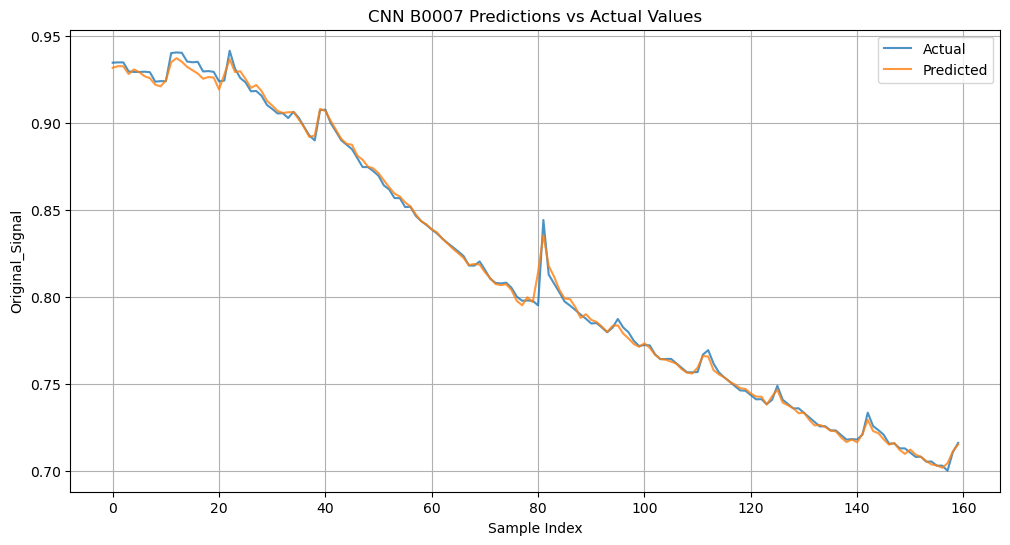


Output shapes:
Actual values shape: (160,)
Predicted values shape: (160,)


In [12]:
 #Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("CNN B0007 Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")

In [13]:
model.summary()
total_params = model.count_params()
print(f"Total trainable parameters in {model.name if hasattr(model, 'name') else 'model'}: {total_params:,}")


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)                    │ (None, 8, 128)              │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_4 (MaxPooling1D)       │ (None, 4, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 4, 64)               │          24,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_5 (MaxPooling1D)       │ (None, 2, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 103,877 (405.77 KB)

 Trainable params: 34,625 (135.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 69,252 (270.52 KB)

Total trainable parameters in sequential_2: 34,625
